# 5-1. 시간대별 평균 처리시간

접수시간대(0~23시) 기준으로 접수→배차, 배차→승차, 접수→승차 평균 처리시간을 확인한다.

- 데이터 출처: **탑승내역_정제** (`data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv`) — 서울시설공단 제공 트립 단위 raw 데이터에서 직접 계산.
- 참고용(핵심 검증 아님): `data/raw/서울시설공단_장애인콜택시 시간대별 대기시간_20251231.csv` — 8~9절 상관관계 확인에만 사용.
- 상세 계획: [`notebooks_docs_lye/5-1_plan_시간대별평균대기시간.md`](../notebooks_docs_lye/5-1_plan_시간대별평균대기시간.md)


In [1]:
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"

TRIP_PATH = PROCESSED_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(TRIP_PATH, TRIP_PATH.exists())


c:\Users\young\my_project\260901_call_taxi_DA\data\processed\서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv True


## 1. 데이터 로드

파생컬럼 파일이 아니라 **`탑승내역_정제` 원데이터에서 직접** 접수→배차/배차→승차/접수→승차를 계산한다. `이용목적`도 함께 로드해 5~6절에서 전일접수 후보 판별에 사용한다.

이 프로젝트의 데이터 사용 원칙에 따라, 로드한 모든 컬럼(`접수일시`/`배차일시`/`승차일시`/`이용목적`)의 결측치를 **파생 계산 전에** 먼저 확인하고 공유한다. `배차일시`/`승차일시` 결측은 "미배차/미탑승"을 의미하므로 0으로 채우지 않고 그대로 NA로 유지한다.


In [2]:
usecols = ["접수일시", "배차일시", "승차일시", "이용목적"]
df = pd.read_csv(TRIP_PATH, usecols=usecols)

print(f"원본 행 수: {len(df):,}")
print()

missing_summary = pd.DataFrame({
    "결측건수": df[usecols].isna().sum(),
})
missing_summary["결측비율(%)"] = (missing_summary["결측건수"] / len(df) * 100).round(2)
print("결측치 확인(파생 계산 전, 원본 기준) — 배차일시/승차일시 결측은 미배차/미탑승을 의미하므로 NA로 유지:")
display(missing_summary)

df["접수일시"] = pd.to_datetime(df["접수일시"], errors="coerce")
df["배차일시"] = pd.to_datetime(df["배차일시"], errors="coerce")
df["승차일시"] = pd.to_datetime(df["승차일시"], errors="coerce")

df = df[(df["접수일시"] >= "2025-01-01") & (df["접수일시"] < "2026-01-01")].copy()
df["접수시간대"] = df["접수일시"].dt.hour

print(f"\n2025년 필터 후 행 수: {len(df):,}")
df.head()


원본 행 수: 1,722,490

결측치 확인(파생 계산 전, 원본 기준) — 배차일시/승차일시 결측은 미배차/미탑승을 의미하므로 NA로 유지:


,결측건수,결측비율(%)
접수일시,0,0.00
배차일시,177594,10.31
승차일시,245361,14.24
이용목적,0,0.00



2025년 필터 후 행 수: 1,722,431


,접수일시,배차일시,승차일시,이용목적,접수시간대
0,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,기타,0
1,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaT,기타,0
2,2025-01-01 00:03:31.230,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,기타,0
3,2025-01-01 00:03:40.573,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,기타,0
4,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,기타,0


## 2. 처리시간 3대 지표 파생

`접수_배차_분`, `배차_승차_분`, `접수_승차_분`을 분 단위로 계산한다. 01/06 노트북과 동일한 기준으로, 시간 역전으로 발생하는 음수 값은 이상치로 보고 `NA` 처리한다(배차일시/승차일시 자체의 결측은 미배차/미탑승을 의미하므로 그대로 NA 유지).


In [3]:
df["접수_배차_분"] = (df["배차일시"] - df["접수일시"]).dt.total_seconds() / 60
df["배차_승차_분"] = (df["승차일시"] - df["배차일시"]).dt.total_seconds() / 60
df["접수_승차_분"] = (df["승차일시"] - df["접수일시"]).dt.total_seconds() / 60

processing_cols = ["접수_배차_분", "배차_승차_분", "접수_승차_분"]

negative_counts = (df[processing_cols] < 0).sum()
print("음수(이상치) 처리시간 건수:")
print(negative_counts)

for col in processing_cols:
    df.loc[df[col] < 0, col] = pd.NA

df[processing_cols].describe(percentiles=[0.5, 0.9])


음수(이상치) 처리시간 건수:
접수_배차_분    0
배차_승차_분    0
접수_승차_분    0
dtype: int64


,접수_배차_분,배차_승차_분,접수_승차_분
count,1.544859e+06,1.477092e+06,1.477092e+06
mean,8.958628e+01,1.852047e+01,1.096706e+02
std,2.903200e+02,8.194122e+00,2.946405e+02
min,1.684500e-01,4.800000e-02,2.980000e-01
50%,1.263038e+01,1.755557e+01,3.380598e+01
90%,1.096482e+02,2.906921e+01,1.335641e+02
max,2.166574e+03,1.414358e+02,2.199786e+03


## 3. 시간대별 집계

`접수시간대`(0~23시) 기준으로 groupby하여 지표별 평균/중앙값/p90/건수를 집계한다.


In [4]:
hourly_summary = (
    df.groupby("접수시간대")
    .agg(
        건수=("접수일시", "size"),
        접수배차_평균=("접수_배차_분", "mean"),
        접수배차_중앙값=("접수_배차_분", "median"),
        접수배차_p90=("접수_배차_분", lambda s: s.quantile(0.9)),
        배차승차_평균=("배차_승차_분", "mean"),
        배차승차_중앙값=("배차_승차_분", "median"),
        배차승차_p90=("배차_승차_분", lambda s: s.quantile(0.9)),
        접수승차_평균=("접수_승차_분", "mean"),
        접수승차_중앙값=("접수_승차_분", "median"),
        접수승차_p90=("접수_승차_분", lambda s: s.quantile(0.9)),
    )
    .reset_index()
    .sort_values("접수시간대")
)

display(hourly_summary)


,접수시간대,건수,접수배차_평균,접수배차_중앙값,접수배차_p90,배차승차_평균,배차승차_중앙값,배차승차_p90,접수승차_평균,접수승차_중앙값,접수승차_p90
0,0,2186,20.601188,12.666000,49.604890,23.927639,23.566917,36.492025,44.607416,39.638392,75.174917
1,1,1330,25.853877,11.986050,79.633870,23.365004,22.864383,36.528650,49.082041,39.416450,106.724117
2,2,2889,68.933852,97.581000,111.903573,23.383451,22.673083,36.370927,92.475196,119.609167,142.233212
3,3,6644,105.305933,126.267900,187.918733,22.774633,21.710558,35.457300,127.140062,146.302808,207.375333
4,4,20267,116.312497,134.323000,164.394913,20.452158,19.363117,31.562673,136.083406,155.383367,186.698102
5,5,22971,101.895801,127.234050,155.234017,21.005699,20.160200,31.969538,121.456423,143.584725,178.389738
6,6,29337,64.917577,49.356717,138.736633,19.911029,18.955717,30.088587,84.360784,68.602833,161.441507
7,7,123646,335.889973,45.986733,1446.303262,19.974633,19.116233,30.012667,366.755335,67.175167,1464.842333
8,8,143757,284.619322,44.830800,1442.535950,19.471824,18.756467,29.024117,311.079510,64.552758,1460.536657
9,9,111417,44.513651,20.285467,74.381548,18.920443,18.208383,28.864883,63.440208,40.210000,95.764950


## 4. ⚠️ 알려진 왜곡: 07/08/10시 급증

07/08/10시 접수→배차 평균이 다른 시간대 대비 비정상적으로 높게 나타난다. 원인은 **"전일접수"**(휠체어 이용 지체·뇌병변 등 대상, 07/08/10시 배차만 신청 가능한 예약콜)가 이 시각에 몰리는데, 배차 확정이 접수 시점이 아니라 실제 탑승 시각 근처에 이루어져서 접수시간 기준 집계에 예약콜의 사전 대기시간이 섞여 들어가기 때문이다.

이 분석(5-1)은 계획대로 전체 트립(즉시콜+예약콜) 기준을 유지하고 이 왜곡 사실만 명시한다. 즉시콜/예약콜 완전 분리는 5-4에서 진행한다.


In [5]:
distorted_hours = [7, 8, 10]
baseline = hourly_summary.loc[
    ~hourly_summary["접수시간대"].isin(distorted_hours), "접수배차_평균"
].mean()

highlight = hourly_summary[hourly_summary["접수시간대"].isin(distorted_hours)][
    ["접수시간대", "접수배차_평균", "건수"]
].copy()
highlight["다른시간대_평균대비_배수"] = (highlight["접수배차_평균"] / baseline).round(1)

print(f"07/08/10시를 제외한 나머지 시간대 접수→배차 평균: {baseline:.1f}분")
display(highlight)


07/08/10시를 제외한 나머지 시간대 접수→배차 평균: 52.3분


,접수시간대,접수배차_평균,건수,다른시간대_평균대비_배수
7,7,335.889973,123646,6.4
8,8,284.619322,143757,5.4
10,10,177.962901,132376,3.4


## 5. "전일접수 제외" 보정 버전

왜곡의 크기를 가늠하기 위해, `이용목적`이 전일접수 후보군(예약기타/예약치료/예약재활/예약통학·출근/예약귀가 — 5-4에서 정의한 매핑과 동일)인 트립을 제외하고 재계산한다.


In [6]:
전일접수_후보_이용목적 = ["예약기타", "예약치료", "예약재활", "예약통학/출근", "예약귀가"]
df["전일접수후보"] = df["이용목적"].isin(전일접수_후보_이용목적)

n_candidate = df["전일접수후보"].sum()
print(f"전일접수 후보 건수: {n_candidate:,} (전체의 {n_candidate / len(df) * 100:.1f}%)")

df_excl = df[~df["전일접수후보"]]

hourly_summary_excl = (
    df_excl.groupby("접수시간대")
    .agg(
        건수=("접수일시", "size"),
        접수배차_평균=("접수_배차_분", "mean"),
    )
    .reset_index()
    .sort_values("접수시간대")
)

compare = hourly_summary[["접수시간대", "접수배차_평균"]].merge(
    hourly_summary_excl[["접수시간대", "접수배차_평균"]],
    on="접수시간대",
    suffixes=("_전체포함", "_전일접수제외"),
)
compare["배수(포함/제외)"] = (
    compare["접수배차_평균_전체포함"] / compare["접수배차_평균_전일접수제외"]
).round(1)

display(compare)


전일접수 후보 건수: 70,952 (전체의 4.1%)


,접수시간대,접수배차_평균_전체포함,접수배차_평균_전일접수제외,배수(포함/제외)
0,0,20.601188,20.601188,1.0
1,1,25.853877,25.853877,1.0
2,2,68.933852,68.933852,1.0
3,3,105.305933,105.305933,1.0
4,4,116.312497,116.312497,1.0
5,5,101.895801,101.898082,1.0
6,6,64.917577,64.917577,1.0
7,7,335.889973,145.387212,2.3
8,8,284.619322,43.140844,6.6
9,9,44.513651,32.808490,1.4


## 6. 보정 비교 시각화

접수→배차 기준으로 "전체(포함)" vs "전일접수 제외" 곡선을 겹쳐 그려 07/08/10시가 얼마나 보정되는지 확인한다. 07시는 제외 후에도 다른 시간대 대비 높게 남는 "부분 해소" 사례라 별도로 주석을 남긴다.


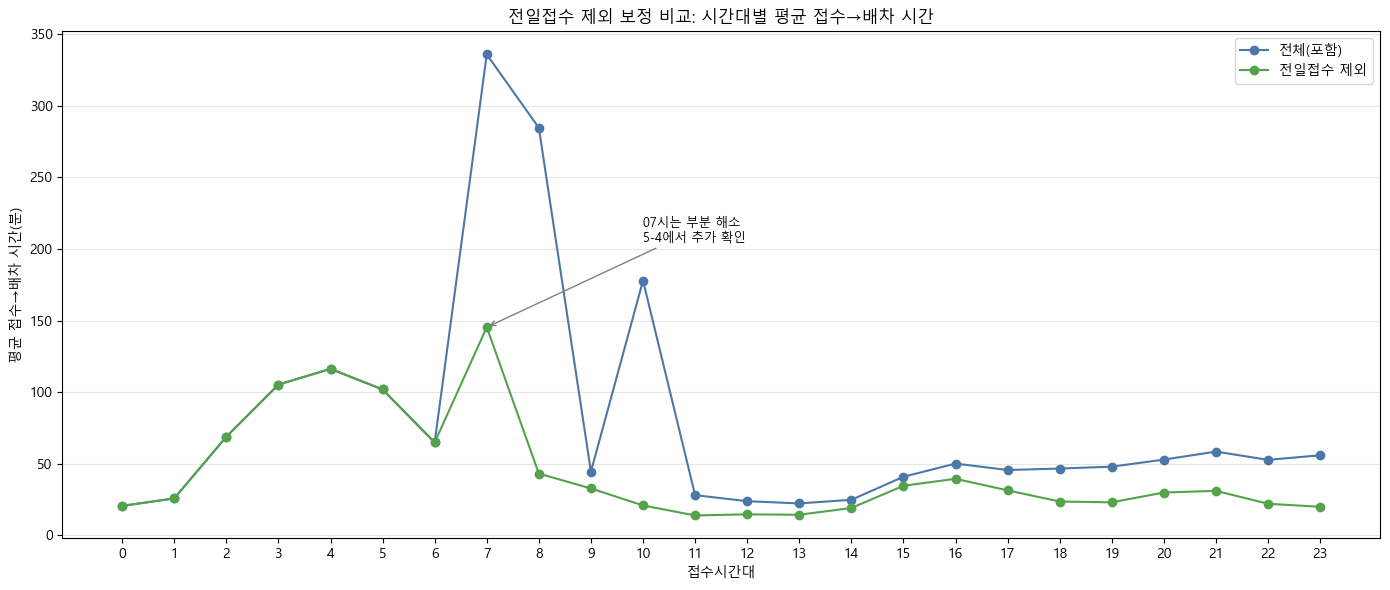

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(
    compare["접수시간대"], compare["접수배차_평균_전체포함"],
    marker="o", label="전체(포함)", color="#4c78a8",
)
plt.plot(
    compare["접수시간대"], compare["접수배차_평균_전일접수제외"],
    marker="o", label="전일접수 제외", color="#54a24b",
)
plt.title("전일접수 제외 보정 비교: 시간대별 평균 접수→배차 시간")
plt.xlabel("접수시간대")
plt.ylabel("평균 접수→배차 시간(분)")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.legend()

row_07 = compare[compare["접수시간대"] == 7].iloc[0]
plt.annotate(
    "07시는 부분 해소\n5-4에서 추가 확인",
    xy=(7, row_07["접수배차_평균_전일접수제외"]),
    xytext=(10, row_07["접수배차_평균_전일접수제외"] + 60),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9,
)
plt.tight_layout()
plt.show()


## 7. (참고, 핵심 아님) 공식 집계와의 상관관계

공식 일별 집계(`일별이용현황`)는 하루 단위라 시간대 breakdown이 없어 검증 근거로 부적절해 제외했다. 대신 시간 단위(일자×시간대)가 있는 공식 raw 파일(`시간대별 대기시간`)과 `탑승내역_정제` 기반 계산을 일자×시간대 기준으로 매칭해 상관계수/MAE를 확인한다. 상관관계가 약해(0.14~0.36) 우리 계산의 신뢰성을 확정하는 핵심 근거로는 쓰지 않는다 — 신뢰성은 01 전처리에서 이미 검증된 로직(음수/결측 처리 등)을 재사용하는 것으로 확보한다.


In [8]:
official_path = RAW_DIR / "서울시설공단_장애인콜택시 시간대별 대기시간_20251231.csv"
official = pd.read_csv(official_path)

official["일자"] = pd.to_datetime(official["일자"]).dt.date
official["시간대_hour"] = pd.to_datetime(official["시간대"], format="%H:%M:%S").dt.hour

df["일자"] = df["접수일시"].dt.date

ours_daily_hourly = (
    df.groupby(["일자", "접수시간대"])
    .agg(
        접수배차_평균=("접수_배차_분", "mean"),
        배차승차_평균=("배차_승차_분", "mean"),
        접수승차_평균=("접수_승차_분", "mean"),
    )
    .reset_index()
)

matched = official.merge(
    ours_daily_hourly,
    left_on=["일자", "시간대_hour"],
    right_on=["일자", "접수시간대"],
    how="inner",
)
print(f"일자×시간대 매칭 건수: {len(matched):,}")

corr_summary = pd.DataFrame({
    "우리 지표": ["접수→배차", "배차→승차", "접수→승차"],
    "상관계수": [
        matched["대기시간평균"].corr(matched["접수배차_평균"]),
        matched["대기시간평균"].corr(matched["배차승차_평균"]),
        matched["대기시간평균"].corr(matched["접수승차_평균"]),
    ],
    "MAE(분)": [
        (matched["대기시간평균"] - matched["접수배차_평균"]).abs().mean(),
        (matched["대기시간평균"] - matched["배차승차_평균"]).abs().mean(),
        (matched["대기시간평균"] - matched["접수승차_평균"]).abs().mean(),
    ],
})

display(corr_summary)


일자×시간대 매칭 건수: 8,714


,우리 지표,상관계수,MAE(분)
0,접수→배차,0.136718,53.932968
1,배차→승차,0.355105,19.561785
2,접수→승차,0.149542,64.283021


## 8. 메인 시각화: 시간대별 처리시간 구성

접수→배차와 배차→승차를 누적 막대로 쌓아 시간대별 전체 처리시간 구성을 확인한다(전체 트립 기준).


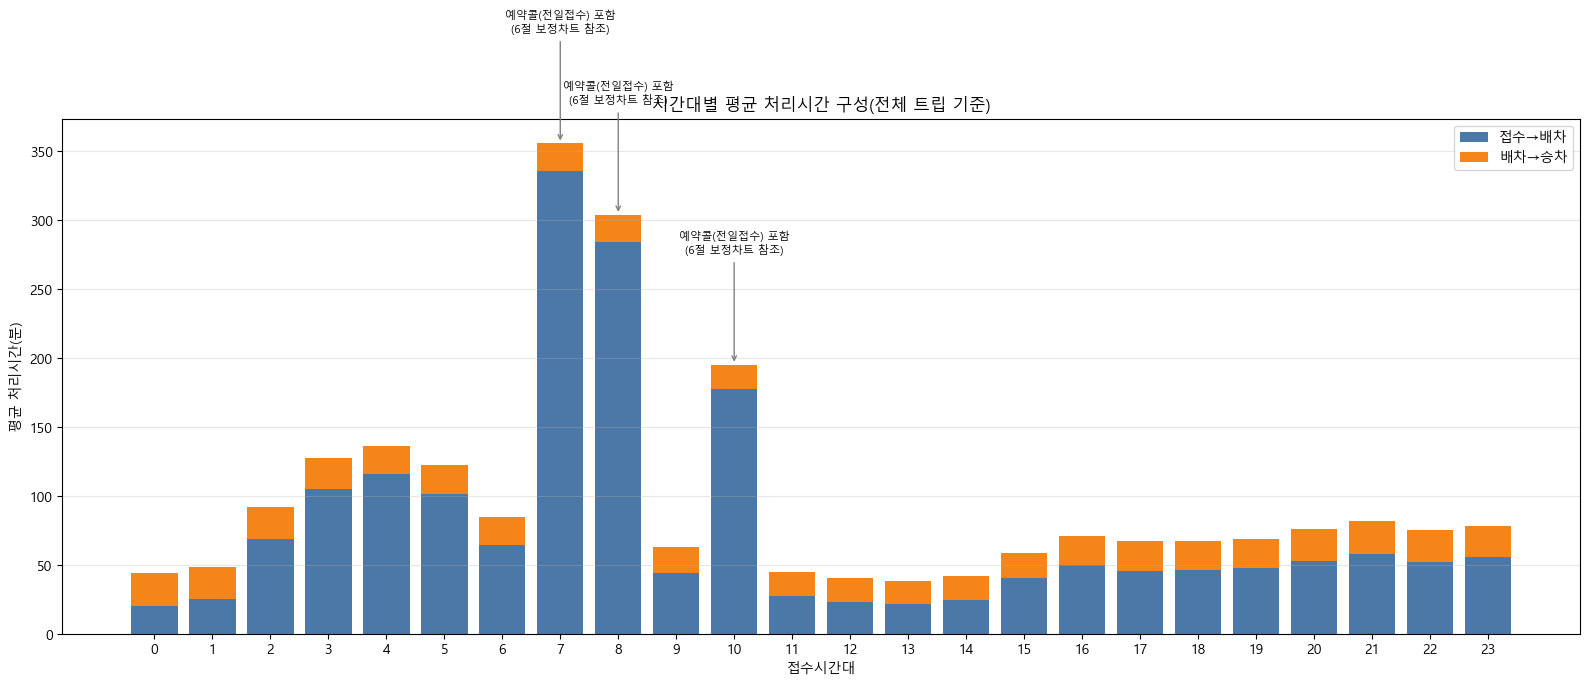

In [9]:
plt.figure(figsize=(16, 7))

x = hourly_summary["접수시간대"]
bottom = hourly_summary["접수배차_평균"]

plt.bar(x, bottom, label="접수→배차", color="#4c78a8")
plt.bar(x, hourly_summary["배차승차_평균"], bottom=bottom, label="배차→승차", color="#f58518")

plt.title("시간대별 평균 처리시간 구성(전체 트립 기준)")
plt.xlabel("접수시간대")
plt.ylabel("평균 처리시간(분)")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.legend()

for h in [7, 8, 10]:
    row = hourly_summary[hourly_summary["접수시간대"] == h].iloc[0]
    total = row["접수배차_평균"] + row["배차승차_평균"]
    plt.annotate(
        "예약콜(전일접수) 포함\n(6절 보정차트 참조)",
        xy=(h, total),
        xytext=(h, total + 80),
        ha="center",
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="gray"),
    )

plt.tight_layout()
plt.show()


## 9. 보조 시각화

누적 막대 차트는 스케일 차이로 배차→승차 구간이 눌려 보이므로, 참고용으로 3개 지표를 겹친 라인 차트를 추가로 제공한다(06 노트북과 동일한 스타일).


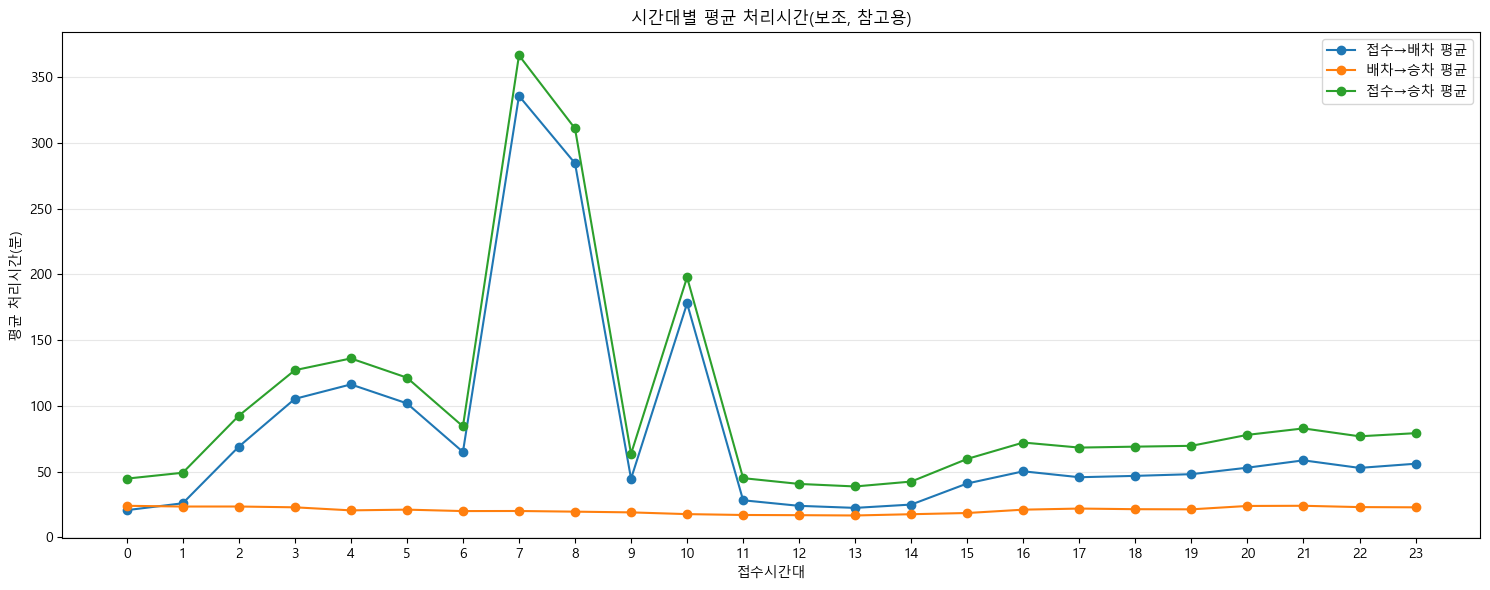

In [10]:
plt.figure(figsize=(15, 6))
plt.plot(hourly_summary["접수시간대"], hourly_summary["접수배차_평균"], marker="o", label="접수→배차 평균")
plt.plot(hourly_summary["접수시간대"], hourly_summary["배차승차_평균"], marker="o", label="배차→승차 평균")
plt.plot(hourly_summary["접수시간대"], hourly_summary["접수승차_평균"], marker="o", label="접수→승차 평균")
plt.title("시간대별 평균 처리시간(보조, 참고용)")
plt.xlabel("접수시간대")
plt.ylabel("평균 처리시간(분)")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 10. 결론 및 다음 단계

- 접수시간대(0~23시) 기준 평균 처리시간을 집계한 결과, 07/08/10시에 접수→배차 시간이 급증하는 왜곡이 관찰된다.
- 전일접수 후보를 제외하면 08시·10시는 정상 범위로 거의 회복되지만, **07시는 다른 시간대 대비 여전히 높게 남아 "부분 해소"로 기록**한다 — 다른 예약성 트립이 일부 섞여 있을 가능성이 있다.
- 완전한 원인 규명·즉시콜/예약콜 분리는 5-4(예약 방법 × 대기시간 비교)로 넘긴다.
- 공식 집계와의 상관관계(7절)는 참고용일 뿐 신뢰성 확정 근거로 쓰지 않는다.
- 다음 단계: 5-2 요일×시간대 히트맵으로 연결.
